In [1]:
from prometheus_pandas import query
import datetime as dt
from zoneinfo import ZoneInfo
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

local_address = "gros-95.nancy.grid5000.fr"
local_port = "30090"
p = query.Prometheus(f"http://admin:prom-operator@{local_address}:{local_port}")    

local_tz = ZoneInfo("Europe/Paris")

def execute_query_range(experiment, metric_query, step, output_filename, plot=False):
    tput_series = []

    print("\nBeginning request execution")
    for label, config in experiment.items():    
        df_metric = p.query_range(
            query=metric_query,
            start=config['start'].isoformat(),
            end=config['end'].isoformat(),
            step=step
        )

        tput_series.append(df_metric)

    if tput_series:
        combined_df = pd.concat(tput_series, axis=1)
        combined_df.to_csv(output_filename, index_label='Time')
        print(f"\nFile saved : '{output_filename}'")
        if plot:
            plt.figure(figsize=(12, 8))
            ax = combined_df.boxplot(grid=True, patch_artist=True)
            plt.title(metric_query)
            plt.show()
    else:
        print("\nRequest Error")

In [18]:
exp_q3 = { #50 000 e/s tput and cp interval = 1min
    'rocks': {
        'start': dt.datetime(2025, 8, 6, 11, 12, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 11, 22, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 6, 11, 33, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 11, 43, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 8, 6, 11, 55, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 12, 5, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 8, 6, 12, 12, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 12, 22, 0, tzinfo=local_tz)
    }
}
exp_q5 = { #5 000 e/s tput and cp interval = 1min
    'rocks': {
        'start': dt.datetime(2025, 8, 5, 15, 28, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 5, 15, 39, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 5, 15, 41, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 5, 15, 51, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 8, 5, 15, 57, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 5, 16, 7, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 8, 5, 16, 14, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 5, 16, 24, 0, tzinfo=local_tz)
    }
}
exp_q8 = { #50 000 e/s tput and cp interval = 1min
    'rocks': {
        'start': dt.datetime(2025, 8, 6, 13, 41, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 13, 51, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 6, 13, 59, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 14, 9, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 8, 6, 14, 19, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 14, 29, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 8, 6, 14, 41, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 6, 14, 51, 0, tzinfo=local_tz)
    }
}
exp_q11 = { #50 000 e/s tput and cp interval = 1min
    'rocks': {
        'start': dt.datetime(2025, 8, 11, 14, 24, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 11, 14, 34, 0, tzinfo=local_tz)
    },
    'forst': {
        'start': dt.datetime(2025, 8, 11, 14, 54, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 11, 15, 4, 0, tzinfo=local_tz)
    },
    'forst_small_cache': {
        'start': dt.datetime(2025, 8, 11, 15, 21, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 11, 15, 31, 0, tzinfo=local_tz)
    },
    'forst_no_cache': {
        'start': dt.datetime(2025, 8, 11, 15, 50, 0, tzinfo=local_tz),
        'end': dt.datetime(2025, 8, 11, 16, 00, 0, tzinfo=local_tz)
    }
}

In [ ]:
metric_query = 'flink_taskmanager_Status_JVM_CPU_Load{component="taskmanager"}'
step = "5s"
output_filename = 'exp2c_q11_cpu_load.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointDuration{component="jobmanager"}'
step = "30s"
output_filename = 'exp2c_q11_cp_time.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_receive_bytes_total{namespace="minio-tenant", pod=~"myminio-.*"}[2m]))'
step = "5s"
output_filename = 'exp2c_q11_minio_bytes.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(flink_taskmanager_job_task_operator_column_family_rocksdb_total_sst_files_size{component="taskmanager"})'
step = "5s"
output_filename = 'exp2c_q11_sst_size.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(container_network_transmit_bytes_total{node="gros-99.nancy.grid5000.fr"}[2m]))'
step = "5s"
output_filename = 'exp2c_q11_bytes_send.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'flink_jobmanager_job_lastCheckpointSize{component="jobmanager"}'
step = "1m"
output_filename = 'exp2c_q11_cp_size.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m]))/(sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_miss{component="taskmanager"}[2m]))+sum(rate(flink_taskmanager_job_task_operator_rocksdb_block_cache_hit{component="taskmanager"}[2m])))'
step = "5s"
output_filename = 'exp2c_q11_cache_hit_ratio.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'rate(minio_bucket_traffic_received_bytes{job="minio"}[2m])'
step = "1m"
output_filename = 'exp2c_q11_bucket_received_bytes_rate.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_rchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp2c_q11_read_bytes_rate.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'rate(minio_node_io_wchar_bytes{job=~"minio"}[2m])'
step = "1m"
output_filename = 'exp2c_q11_write_bytes_rate.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum(minio_node_drive_used_bytes{job=~"minio"})'
step = "1m"
output_filename = 'exp2c_q11_drive_used_bytes.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = 'sum by (api) (minio_node_drive_latency_us{job=~"minio"})'
step = "1m"
output_filename = 'exp2c_q11_operation_latency.csv'
execute_query_range(exp_q11, metric_query, step, output_filename)

metric_query = '(increase(minio_bucket_requests_total{job="minio"}[2m]))'
step = "1m"
output_filename = 'exp2c_q11_operation_request_rate.csv' #type of operation (create/get/delete/... and its rate)
execute_query_range(exp_q11, metric_query, step, output_filename)


Beginning request execution

File saved : 'exp2c_q11_cpu_load.csv'

Beginning request execution

File saved : 'exp2c_q11_cp_time.csv'

Beginning request execution

File saved : 'exp2c_q11_minio_bytes.csv'

Beginning request execution

File saved : 'exp2c_q11_sst_size.csv'

Beginning request execution

File saved : 'exp2c_q11_bytes_send.csv'

Beginning request execution

File saved : 'exp2c_q11_cp_size.csv'

Beginning request execution

File saved : 'exp2c_q11_cache_hit_ratio.csv'

Beginning request execution

File saved : 'exp2c_q11_bucket_received_bytes_rate.csv'

Beginning request execution

File saved : 'exp2c_q11_read_bytes_rate.csv'

Beginning request execution

File saved : 'exp2c_q11_write_bytes_rate.csv'

Beginning request execution

File saved : 'exp2c_q11_drive_used_bytes.csv'

Beginning request execution

File saved : 'exp2c_q11_operation_latency.csv'

Beginning request execution

File saved : 'exp2c_q11_operation_request_rate.csv'


### BoxPlot

In [48]:
file_path = 'q11/exp2c_q11_operation_latency.csv'

try:
    df = pd.read_csv(file_path, index_col=0)
    
    df.columns = ['rocks', 'forst', 'forst_small_cache', 'forst_no_cache']
    #df = df.iloc[:, :-1] 
    plt.figure(figsize=(12, 10))
    df.plot(grid=True, ax=plt.gca()) #style='o'
    #df.boxplot(grid=True, patch_artist=True)
    plt.title('Read bytes rate over time per configuration for q11')
    plt.ylabel('Bytes/sec')
    plt.xlabel('Time')
    plt.xticks([])
    #plt.yticks(np.arange(0, plt.ylim()[1], 20000))
    plt.savefig('q11/exp2c_q11_operation_latency.png')
    
    plt.show()
    
except FileNotFoundError:
    print(f"Le fichier '{file_path}' est introuvable.")
except Exception as e:
    print(f"Une erreur est survenue : {e}")

Une erreur est survenue : Length mismatch: Expected axis has 60 elements, new values have 4 elements


La figure avec la légende interne a été sauvegardée.


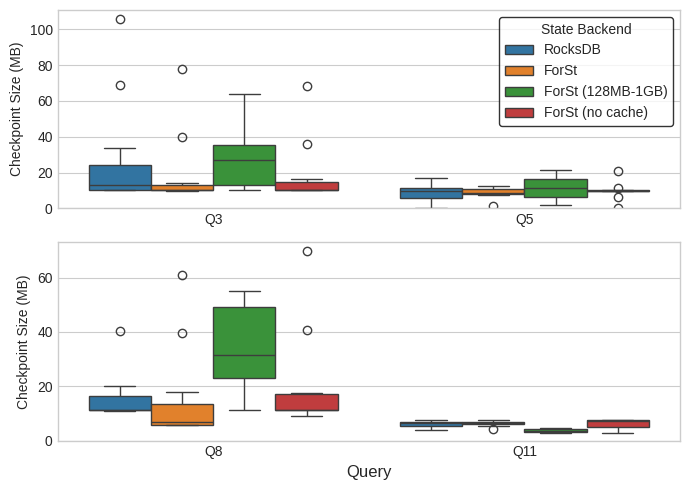

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import numpy as np

def draw_boxplots_on_axis(ax, file_list, show_legend=True):
    """
    Dessine les boxplots pour une liste de fichiers sur un axe matplotlib donné.
    """
    all_data = []
    custom_column_names = ['Time', 'RocksDB', 'ForSt', 'ForSt (128MB-1GB)', 'ForSt (no cache)']

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"Attention: Le fichier {file_path} est introuvable.")
            continue
        
        match = re.search(r'q(\d+)_cpu_load\.csv', file_path)
        
        if not match:
            continue
            
        query_num = f"Q{match.group(1)}"
        df = pd.read_csv(file_path)
        
        current_cols = custom_column_names[:df.shape[1]]
        df.columns = current_cols
        
        for col_name in current_cols:
            if col_name != 'Time' and not df[col_name].isnull().all():
                bytes_to_mb = 1024 * 1024
                temp_df = pd.DataFrame({
                    'Throughput': df[col_name].dropna() / bytes_to_mb,
                    'State Backend': col_name,
                    'Query': query_num
                })
                all_data.append(temp_df)

    if not all_data:
        ax.text(0.5, 0.5, 'Aucune donnée à afficher', ha='center', va='center')
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    query_order = sorted(combined_df['Query'].unique(), key=lambda q: int(q[1:]))

    sns.boxplot(
        x='Query',
        y='Throughput',
        hue='State Backend',
        data=combined_df,
        order=query_order,
        ax=ax
    )
    
    # --- MODIFICATION 1 : Changer les paramètres de la légende ---
    if show_legend:
        ax.legend(
            title='State Backend',
            loc='upper right',    # Positionne la légende en haut à droite, à l'intérieur
            frameon=True,         # Active le cadre
            facecolor='white',    # Fond de la légende en blanc
            edgecolor='black',    # Bordure du cadre en noir
            framealpha=0.8        # Légère transparence pour ne pas masquer les données
        )
    else:
        if ax.get_legend() is not None:
            ax.get_legend().remove()

    ax.set_xlabel('')
    ax.set_ylabel('Checkpoint Size (MB)')

# --- Script principal pour créer la figure combinée ---

# NOTE: J'adapte les chemins pour que le code fonctionne avec les fichiers fournis.
files_for_bottom_plot = ["q11/exp2c_q11_cp_size.csv", "q8/exp2c_q8_cp_size.csv"]

files_for_top_plot = ["q5/exp2c_q5_cp_size.csv", "q3/exp2c_q3_cp_size.csv"]

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 5))

draw_boxplots_on_axis(ax1, files_for_top_plot, show_legend=True)

draw_boxplots_on_axis(ax2, files_for_bottom_plot, show_legend=False)
ax2.set_xlabel('Query', fontsize=12)

ax1.set_ylim(bottom=0)
ax2.set_ylim(bottom=0)

# --- MODIFICATION 2 : Simplifier tight_layout ---
# L'argument 'rect' n'est plus nécessaire car la légende est à l'intérieur
fig.tight_layout() 
plt.savefig('exp2c_cp_size_boxplot_legend_inside.png', dpi=150)

print("La figure avec la légende interne a été sauvegardée.")

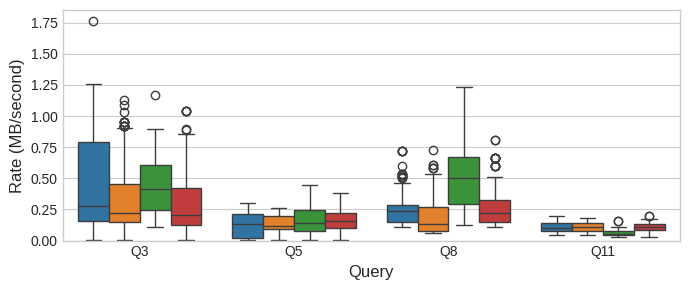

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re

def plot_combined_boxplots_custom_names(file_list):
    """
    Crée un diagramme de boxplots groupés avec des noms de backend personnalisés.
    """
    all_data = []
    custom_column_names = ['Time', 'RocksDB', 'ForSt', 'ForSt (128MB-1GB)', 'ForSt (no cache)']

    for file_path in file_list:
        if not os.path.exists(file_path):
            print(f"Attention : Le fichier {file_path} n'a pas été trouvé.")
            continue

        match = re.search(r'q(\d+)_minio_bytes\.csv', file_path)
        if not match:
            continue
        query_num = f"Q{match.group(1)}"

        df = pd.read_csv(file_path)
        
        if df.shape[1] != len(custom_column_names):
             temp_cols = custom_column_names[:df.shape[1]]
             df.columns = temp_cols
        else:
            df.columns = custom_column_names

        for col_name in df.columns:
            if col_name != 'Time' and not df[col_name].isnull().all():
                temp_df = pd.DataFrame({
                    # Note: J'ai conservé le nom 'Throughput' comme dans votre code
                    'Throughput': df[col_name].dropna()/ (1024*1024),
                    'Backend': col_name,
                    'Query': query_num
                })
                all_data.append(temp_df)

    if not all_data:
        print("Aucune donnée n'a pu être traitée. Vérifiez vos fichiers.")
        return

    combined_df = pd.concat(all_data, ignore_index=True)
    query_order = sorted(combined_df['Query'].unique(), key=lambda q: int(q[1:]))

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(7, 3))
    sns.boxplot(
        x='Query',
        y='Throughput',
        hue='Backend',
        data=combined_df,
        order=query_order,
        ax=ax,
        legend=False
    )

    ax.set_xlabel('Query',fontsize=12)
    ax.set_ylabel('Rate (MB/second)',fontsize=12) # J'ai adapté ce label
    ax.set_ylim(0)
    # --- MODIFICATION 1 : Changer les paramètres de la légende ---
    # Le formatage en 'k' peut ne pas être pertinent ici, je le commente
    # ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x/1000)}k'))

    # --- MODIFICATION 2 : Simplifier tight_layout ---
    # L'argument 'rect' n'est plus nécessaire car la légende est à l'intérieur
    plt.tight_layout()
    plt.savefig('minio_bytes_bplot.pdf')

# --- Utilisation du script --
# Assurez-vous que ces chemins d'accès sont corrects sur votre machine
files_to_analyze = ["q11/exp2c_q11_minio_bytes.csv", "q8/exp2c_q8_minio_bytes.csv", "q5/exp2c_q5_minio_bytes.csv", "q3/exp2c_q3_minio_bytes.csv"]

# Note: Le script ne pourra pas s'exécuter si les fichiers ne sont pas trouvés.
# S'il fonctionne pour vous, il produira le graphique avec la légende interne.
plot_combined_boxplots_custom_names(files_to_analyze)

Le graphique a été sauvegardé sous '1ktput/exp1a_1k_operation_request_rate_boxplot_filled.pdf'


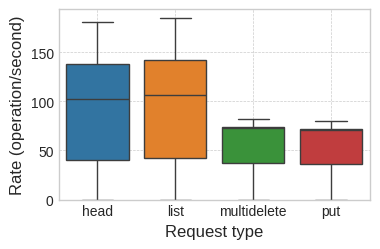

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime as dt
from zoneinfo import ZoneInfo
import seaborn as sns # On utilise Seaborn pour le tracé

def plot_rocksdb_operations_boxplot(csv_file, start_time, end_time):
    """
    Charge les données de débit des opérations MinIO, filtre pour l'expérience RocksDB
    et pour des colonnes spécifiques, puis génère un boxplot avec des boîtes pleines.
    """
    try:
        df = pd.read_csv(csv_file, index_col='Time', parse_dates=True)

        # Localiser l'index
        try:
            df.index = df.index.tz_localize('Europe/Paris')
        except TypeError:
            df.index = df.index.tz_convert('Europe/Paris')

        def clean_col_name(col_name):
            match = re.search(r'api="([^"]+)"', col_name)
            return match.group(1) if match else col_name
        df.columns = [clean_col_name(col) for col in df.columns]

        rocks_df = df.loc[start_time:end_time].copy()

        # On ne garde que les colonnes spécifiées
        columns_to_keep = [
            'headobject',
            'listobjectsv2',
            'deletemultipleobjects',
            'putobject',
            'getobject',

        ]
        existing_columns = [col for col in columns_to_keep if col in rocks_df.columns]
        
        if not existing_columns:
            print("Aucune des colonnes spécifiées n'a été trouvée dans les données.")
            return
            
        rocks_df = rocks_df[existing_columns]

        if rocks_df.empty:
            print("Aucune donnée trouvée pour la période spécifiée.")
            return

        active_operations_df = rocks_df.loc[:, (rocks_df.sum(numeric_only=True) > 0)]

        if active_operations_df.empty:
            print("Aucune opération avec un débit > 0 n'a été trouvée pour les colonnes sélectionnées.")
            return
        new_axis_labels = {
            'getobject': 'get',
            'headobject': 'head',
            'listobjectsv2': 'list',
            'deletemultipleobjects': 'multidelete',
            'putobject': 'put',
            
        }
        active_operations_df = active_operations_df.rename(columns=new_axis_labels)
        # --- MODIFICATION : Utilisation de Seaborn pour un boxplot plein ---
        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(3*1.3,2*1.3))
        
        # On remplace la fonction de Pandas par celle de Seaborn
        # qui crée des boîtes pleines par défaut.
        sns.boxplot(data=active_operations_df, ax=ax)
        ax.set_xlabel('Request type', fontsize=12)
        ax.set_ylabel('Rate (operation/second)', fontsize=12)
        
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_ylim(0)
        plt.tight_layout()
        plt.savefig('operation_request_rate_rocks.pdf')
        print("Le graphique a été sauvegardé sous '1ktput/exp1a_1k_operation_request_rate_boxplot_filled.pdf'")
        plt.show()

    except FileNotFoundError:
        print(f"Le fichier '{csv_file}' est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")


# --- Utilisation ---
local_tz = ZoneInfo("Europe/Paris")

rocksdb_start_corrected = dt.datetime(2025, 8, 5, 14, 14, 00, tzinfo=local_tz)
rocksdb_end_corrected = dt.datetime(2025, 8, 5, 14, 22, 0, tzinfo=local_tz)
csv_filename = 'q5/exp2c_q5_operation_request_rate.csv'

plot_rocksdb_operations_boxplot(csv_filename, rocksdb_start_corrected, rocksdb_end_corrected)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import re
import datetime as dt
from zoneinfo import ZoneInfo

def plot_rocksdb_operations(csv_file, start_time, end_time):
    """
    Charge les données de débit des opérations MinIO, filtre pour l'expérience RocksDB
    et génère un graphique.
    """
    try:
        df = pd.read_csv(csv_file, index_col='Time', parse_dates=True)

        # Localiser l'index pour le rendre "aware"
        try:
            df.index = df.index.tz_localize('Europe/Paris')
        except TypeError:
            # Gère le cas où l'index est déjà localisé
            df.index = df.index.tz_convert('Europe/Paris')

        # --- ASTUCE DE DÉBOGAGE ---
        # print("Plage horaire réelle du fichier :")
        # print(f"Début : {df.index.min()}")
        # print(f"Fin   : {df.index.max()}")
        
        def clean_col_name(col_name):
            match = re.search(r'api="([^"]+)"', col_name)
            return match.group(1) if match else col_name
        df.columns = [clean_col_name(col) for col in df.columns]

        rocks_df = df.loc[start_time:end_time].copy()

        if rocks_df.empty:
            print("Aucune donnée trouvée pour la période spécifiée. Vérifiez les dates.")
            return

        active_operations_df = rocks_df.loc[:, (rocks_df.sum(numeric_only=True) > 0)]

        if active_operations_df.empty:
            print("Aucune opération avec un débit > 0 n'a été trouvée.")
            return

        plt.style.use('seaborn-v0_8-whitegrid')
        fig, ax = plt.subplots(figsize=(14, 8))
        #active_operations_df.plot(ax=ax, style='-o', markersize=4)
        #active_operations_df.plot(ax=ax, stacked=True)
# --- MODIFICATION : Utilisation de ax.stackplot() ---
        # Préparer les données pour la fonction
        x_data = active_operations_df.index
        # .stackplot attend une séquence de tableaux 1D, on transpose le DataFrame
        y_data = active_operations_df.T.values 
        labels = active_operations_df.columns

        # Créer le graphique en aires empilées
        ax.stackplot(x_data, y_data, labels=labels)
        ax.set_title('Débit des opérations MinIO pour le backend RocksDB (Requête Q11)', fontsize=16)
        ax.set_xlabel('Heure', fontsize=12)
        ax.set_ylabel('Taux de requêtes (opérations/seconde)', fontsize=12)
        ax.legend(title='Opération MinIO', bbox_to_anchor=(1.02, 1), loc='upper left')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        
        plt.tight_layout(rect=[0, 0, 0.85, 1])
        plt.savefig('exp2c_q8_operation_request_rate.png')
        print("Le graphique a été sauvegardé sous 'exp2c_q3_rocksdb_operations.png'")
        plt.show()

    except FileNotFoundError:
        print(f"Le fichier '{csv_file}' est introuvable.")
    except Exception as e:
        print(f"Une erreur est survenue : {e}")


# --- Utilisation avec les heures corrigées ---
local_tz = ZoneInfo("Europe/Paris")

# On utilise maintenant la plage horaire de 13h, qui correspond aux données du fichier
rocksdb_start_corrected = dt.datetime(2025, 8, 6, 12, 41, 0, tzinfo=local_tz)
rocksdb_end_corrected = dt.datetime(2025, 8, 6, 12, 51, 0, tzinfo=local_tz)
csv_filename = 'exp2c_q8_operation_request_rate.csv'

plot_rocksdb_operations(csv_filename, rocksdb_start_corrected, rocksdb_end_corrected)

Le fichier 'exp2c_q8_operation_request_rate.csv' est introuvable.


In [7]:
import pandas as pd
import re

def make_names_unique(column_names):
    """
    Prend une liste de noms de colonnes et la rend unique en ajoutant des suffixes
    aux doublons (ex: ['A', 'B', 'A'] -> ['A', 'B', 'A_2']).
    """
    counts = {}
    unique_names = []
    for name in column_names:
        if name in counts:
            counts[name] += 1
            unique_names.append(f"{name}_{counts[name]}")
        else:
            counts[name] = 1
            unique_names.append(name)
    return unique_names

def rename_csv_columns_from_api_key(input_filename, output_filename):
    """
    Lit un fichier CSV, extrait l'ID de la clé 'api' dans les en-têtes,
    assure l'unicité des noms, et sauvegarde un nouveau fichier.
    """
    try:
        header_list = pd.read_csv(input_filename, nrows=0).columns.tolist()
        
        new_column_names = []
        api_pattern = re.compile(r'api="([^"]+)"')

        for column_name in header_list:
            match = api_pattern.search(column_name)
            if match:
                new_column_names.append(match.group(1))
            else:
                new_column_names.append(column_name)
        
        # --- CORRECTION : Assurer que tous les noms de colonnes sont uniques ---
        final_column_names = make_names_unique(new_column_names)
        
        # Lire le fichier CSV complet avec les noms de colonnes uniques et corrigés
        df = pd.read_csv(input_filename, skiprows=1, names=final_column_names)
        
        df.to_csv(output_filename, index=False)
        
        print(f"Succès ! Le fichier a été sauvegardé avec les colonnes renommées ici : '{output_filename}'")
        print("\nVoici un aperçu des 5 premiers nouveaux noms de colonnes :")
        print(final_column_names[:5])
        print("\nVoici un aperçu des 5 dernières colonnes pour vérifier les doublons renommés :")
        print(final_column_names[-5:])


    except FileNotFoundError:
        print(f"Erreur : Le fichier '{input_filename}' est introuvable.")
    except Exception as e:
        print(f"Une erreur inattendue est survenue : {e}")


# --- Utilisation du script ---
input_csv = 'exp2c_q3_operation_request_rate.csv'
output_csv = 'exp2c_q3_operations_renamed.csv'

rename_csv_columns_from_api_key(input_csv, output_csv)

Succès ! Le fichier a été sauvegardé avec les colonnes renommées ici : 'exp2c_q3_operations_renamed.csv'

Voici un aperçu des 5 premiers nouveaux noms de colonnes :
['Time', 'completemultipartupload', 'deletemultipleobjects', 'deleteobject', 'getbucketlocation']

Voici un aperçu des 5 dernières colonnes pour vérifier les doublons renommés :
['listobjectsv2_4', 'newmultipartupload_4', 'putbucket_4', 'putobject_4', 'putobjectpart_4']


In [6]:
import pandas as pd
import re

def sum_by_api_key(input_filename, output_filename):
    """
    Lit un fichier CSV de latences, groupe les colonnes par la clé 'api'
    et somme leurs valeurs, simulant un 'sum by (api)' de Prometheus.

    Args:
        input_filename (str): Le chemin vers le fichier CSV d'origine.
        output_filename (str): Le nom du nouveau fichier CSV agrégé à créer.
    """
    try:
        # 1. Charger le fichier CSV, en utilisant la première colonne 'Time' comme index
        df = pd.read_csv(input_filename, index_col=0, parse_dates=True)
        
        # 2. Créer une liste contenant l'identifiant 'api' de chaque colonne
        api_labels = []
        api_pattern = re.compile(r'api="([^"]+)"')

        for column_name in df.columns:
            match = api_pattern.search(column_name)
            if match:
                api_labels.append(match.group(1))
            else:
                # Si une colonne n'a pas de clé 'api', on garde son nom
                # pour ne pas la perdre, mais elle ne sera pas groupée.
                api_labels.append(column_name)
        
        # 3. Grouper le DataFrame par les labels d'api extraits et sommer les valeurs.
        # L'argument axis=1 est crucial, il indique de grouper les COLONNES.
        summed_df = df.groupby(by=api_labels, axis=1).sum()
        
        # 4. Sauvegarder le DataFrame agrégé dans un nouveau fichier
        summed_df.to_csv(output_filename)
        
        print(f"Succès ! Le fichier agrégé a été sauvegardé ici : '{output_filename}'")
        print("\nVoici un aperçu des colonnes du nouveau fichier :")
        print(summed_df.columns.tolist())
        print("\nEt un aperçu des 5 premières lignes de données :")
        print(summed_df.head())

    except FileNotFoundError:
        print(f"Erreur : Le fichier '{input_filename}' est introuvable.")
    except Exception as e:
        print(f"Une erreur inattendue est survenue : {e}")


# --- Utilisation du script ---
# Nom du fichier d'entrée
input_csv = 'exp2c_q8_operation_latency.csv'
# Nom que vous souhaitez donner au nouveau fichier agrégé
output_csv = 'exp2c_q8_latency_sum_by_api.csv'

# Lancer la fonction
sum_by_api_key(input_csv, output_csv)

Succès ! Le fichier agrégé a été sauvegardé ici : 'exp2c_q8_latency_sum_by_api.csv'

Voici un aperçu des colonnes du nouveau fichier :
['storage.CreateFile', 'storage.Delete', 'storage.DeleteBulk', 'storage.DeleteVersion', 'storage.DeleteVersions', 'storage.DiskInfo', 'storage.ListVols', 'storage.MakeVol', 'storage.ReadParts', 'storage.ReadVersion', 'storage.ReadXL', 'storage.RenameData', 'storage.RenamePart', 'storage.WalkDir', 'storage.WriteMetadata']

Et un aperçu des 5 premières lignes de données :
                     storage.CreateFile  storage.Delete  storage.DeleteBulk  \
Time                                                                          
2025-08-06 11:41:00            202528.0           283.0               196.0   
2025-08-06 11:42:00            202528.0           283.0               196.0   
2025-08-06 11:43:00            312118.0           303.0               264.0   
2025-08-06 11:44:00            345281.0           272.0               283.0   
2025-08-06 11:45:0

/tmp/ipykernel_34440/1008662506.py:32: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  summed_df = df.groupby(by=api_labels, axis=1).sum()
